# Monte Carlo Simulation

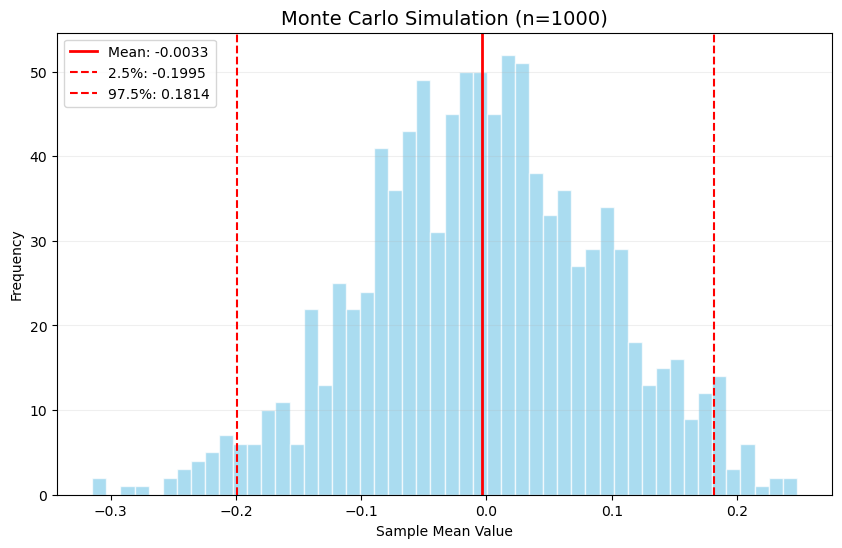

In [59]:
import numpy as np
import matplotlib.pyplot as plt

class MonteCarloSimulator:
    def __init__(self):
        self.data_pool = None
        self.means = None

    def create_source_data(self, size=1000000):
        """Generates the initial Standard Normal pool."""
        self.data_pool = np.random.standard_normal(size)

    def run_simulation(self, n, m):
        """Perform n simulations of size m."""
        if self.data_pool is None or n * m > len(self.data_pool):
            self.create_source_data(max(1000000, n * m))

        samples = self.data_pool[:n*m].reshape(n, m)
        self.means = samples.mean(axis=1)

    def plot_results(self):
        """Visualizes means with red markers for Mean and 95% Percentiles."""
        if self.means is None:
            return

        # 1. Calculate Stats
        mu = np.mean(self.means)
        p_low = np.percentile(self.means, 2.5)
        p_high = np.percentile(self.means, 97.5)

        # 2. Create Plot
        plt.figure(figsize=(10, 6))
        plt.hist(self.means, bins=50, color='skyblue', edgecolor='white', alpha=0.7)

        # 3. Add Red Lines
        # Mean line (solid)
        plt.axvline(mu, color='red', linestyle='-', linewidth=2, label=f'Mean: {mu:.4f}')
        
        # Percentile lines (dashed)
        plt.axvline(p_low, color='red', linestyle='--', linewidth=1.5, label=f'2.5%: {p_low:.4f}')
        plt.axvline(p_high, color='red', linestyle='--', linewidth=1.5, label=f'97.5%: {p_high:.4f}')

        # 4. Formatting
        plt.title(f"Monte Carlo Simulation (n={len(self.means)})", fontsize=14)
        plt.xlabel("Sample Mean Value")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(axis='y', alpha=0.2)
        plt.show()

# --- Running with different numbers ---
sim = MonteCarloSimulator()

# Run 1: Smaller sample (wider spread)
sim.run_simulation(n=1000, m=100)
sim.plot_results()
